In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import scene_generation.core as core_mod
import time

from pathlib import Path
from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size
from collections import Counter
from matplotlib.patches import Patch
from PIL import Image, ImageDraw
from sionna.rt import scene, preview

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Scene center (only need to update CENTER_LON, CENTER_LAT, DATA_DIR_LIDAR_OSM, DATA_DIR_OVERTURE and run the rest of the cells to receive full analysis)
# DuPont Circle: -77.043446, 38.909647
# Duke Wilkinson area: -78.940297, 36.002556
# Flatiron Building: -73.9897, 40.7411
CENTER_LON = -74.00361
CENTER_LAT  = 40.715

SCENE_WIDTH  = 500   # east–west extent, metres
SCENE_HEIGHT = 500   # north–south extent, metres

DATA_DIR = "./scenes/nyc_cityhall_example_overture_without_lidar"

OSM_SERVER = "http://10.237.198.210:3452/api/interpreter"

In [3]:
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(DATA_DIR)}")

Output directory: /home/rt279/geo2sigmap-fork/research/examples/scenes/nyc_cityhall_example_overture_without_lidar


Using Overture release: s3://overturemaps-us-west-2/release/2026-06-17.0/theme=buildings/type=building/*


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Using Overture release: s3://overturemaps-us-west-2/release/2026-06-17.0/theme=buildings/type=building_part/*


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Parsing buildings:  46%|████▌     | 94/204 [00:00<00:00, 472.44it/s]Building part 4ee86d47-d40e-37c0-9f3f-412e1cc9f68d top height 49.00 exceeds parent building ef993039-cc78-401f-9409-e394085398da top height 30.14; treating min_height/min_floor as 0 for the part
Building part aeab0e2f-7afa-32f0-8a7b-5546a9f1799e top height 41.00 exceeds parent building ef993039-cc78-401f-9409-e394085398da top height 30.14; treating min_height/min_floor as 0 for the part
Building part ca70ccec-6215-341f-a6c9-9f0ee2252119 top height 179.00 exceeds parent building b595926c-7542-493e-b15a-a4e97b2e1c1e top height 17.50; treating min_height/min_floor as 0 for the part
Building part f87d07ec-7833-3135-b847-1b0f8165b6f3 top height 165.00 exceeds parent building b595926c-7542-493e-b15a-a4e97b2e1c1e top height 10.50; treating min_height/min_floor as 0 for the part
Building part bcbc5f8b-d14e-3da3-a045-49ce36f03cf4 top height 170.00 exceeds parent building cfed0fc0-a699-444f-be31-dc1c7fbabcd8 top height 20.00; tr

Scene generation complete!


,runtime_seconds
0,25.438722


,height_source,building_count,building_percentage
0,overture:height,303,95.28%
1,fallback:random,11,3.46%
2,overture:num_floors,4,1.26%


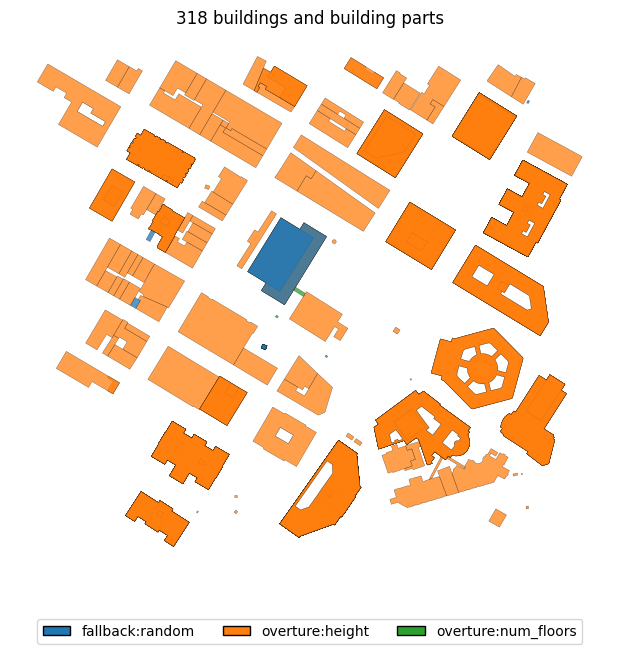

LiDAR HAG raster exists : False


In [4]:
def summarize_height_sources(height_sources):
    """Summarize counts and percentages of buildings by selected height source."""
    total_buildings = sum(height_sources.values())
    rows = []

    for source, building_count in height_sources.most_common():
        building_percentage = (
            (building_count / total_buildings) * 100 if total_buildings else 0.0
        )
        rows.append(
            {
                "height_source": source,
                "building_count": building_count,
                "building_percentage": f"{building_percentage:.2f}%",
            }
        )

    return pd.DataFrame(
        rows,
        columns=["height_source", "building_count", "building_percentage"],
    )


def iter_polygons(geometry):
    """Yield polygon parts from a Shapely Polygon or MultiPolygon."""
    if geometry is None or geometry.is_empty:
        return

    if geometry.geom_type == "Polygon":
        yield geometry
    elif geometry.geom_type == "MultiPolygon":
        yield from geometry.geoms


def plot_height_source_footprints(
    records, *, figsize=(14, 7), alpha=0.75
):
    """Plot building footprints, colored by height source."""
    all_sources = sorted(
        {
            record["height_source"]
            for record in records
        }
    )
    cmap = plt.get_cmap("tab10")
    source_colors = {
        source: cmap(index % cmap.N) for index, source in enumerate(all_sources)
    }

    fig, axes = plt.subplots(1, 1, figsize=figsize)
    for record in records:
        source = record["height_source"]
        for polygon in iter_polygons(record["footprint"]):
            x, y = polygon.exterior.xy
            axes.fill(
                x,
                y,
                facecolor=source_colors[source],
                edgecolor="black",
                linewidth=0.2,                    alpha=alpha,
            )
            for interior in polygon.interiors:
                hole_x, hole_y = interior.xy
                axes.fill(
                    hole_x,
                    hole_y,
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.2,
                )

    axes.set_title(f"{len(records)} buildings and building parts")
    axes.set_aspect("equal", adjustable="box")
    axes.axis("off")

    legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=source)
        for source, color in source_colors.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=max(1, min(4, len(legend_handles))),
    )
    return fig, axes


def rasterize_height_source_mask(records, height_source, shape, ground_bounds):
    """Rasterize footprints for one height source onto a building-map grid."""
    min_x, _, _, max_y = ground_bounds
    mask_image = Image.new("1", (shape[1], shape[0]), 0)
    draw = ImageDraw.Draw(mask_image)

    for record in records:
        if record["height_source"] != height_source:
            continue

        for polygon in iter_polygons(record["footprint"]):
            pixel_coords = [(x - min_x, max_y - y) for x, y in polygon.exterior.coords]
            draw.polygon(pixel_coords, outline=1, fill=1)

    return np.array(mask_image, dtype=bool)


def generate_scene(out_dir, *, track_height_sources=False):
    """Generate the scene and optionally count selected height sources."""
    scene_polygon = rect_from_point_and_size(
    CENTER_LON, CENTER_LAT, "center", SCENE_WIDTH, SCENE_HEIGHT
    )

    height_sources = []
    height_source_records = []
    original_resolve = core_mod.resolve_building_height

    def logging_resolve_building_height(*args, **kwargs):
        kwargs = dict(kwargs)
        kwargs["return_source"] = True
        height, metadata = original_resolve(*args, **kwargs)
        source = metadata.get("source", "unknown")
        footprint = args[1] if len(args) > 1 else kwargs.get("building_polygon")
        height_sources.append(source)
        height_source_records.append(
            {
                "height_source": source,
                "height_m": height,
                "footprint": footprint,
            }
        )
        return height

    if track_height_sources:
        core_mod.resolve_building_height = logging_resolve_building_height

    try:
        scene = Scene()
        building_height_map = scene(
            points=scene_polygon,
            data_dir=out_dir,
            hag_tiff_path=None,  # None lets lidar-osm create/reuse out_dir/test_hag.tif
            ground_material_type="mat-itu_wet_ground",
            rooftop_material_type="mat-itu_metal",
            wall_material_type="mat-itu_concrete",
            generate_building_map=True,
            lidar_height_calibration=False,
            #lidar_terrain=False,
            # dem_terrain=False,
        )
        ground_bounds = scene._ground_polygon_envelope_UTM.bounds
    finally:
        if track_height_sources:
            core_mod.resolve_building_height = original_resolve

    return building_height_map, Counter(height_sources), height_source_records, ground_bounds

scene_generation_runtimes = []

# start_time = time.perf_counter()
# lidar_height_map, lidar_height_sources, lidar_height_source_records, lidar_ground_bounds = generate_scene(
#     "lidar-osm", DATA_DIR_LIDAR_OSM, track_height_sources=True
# )
# scene_generation_runtimes.append(
#     {"mode": "lidar-osm", "runtime_seconds": time.perf_counter() - start_time}
# )

start_time = time.perf_counter()
overture_height_map, overture_height_sources, overture_height_source_records, overture_ground_bounds = generate_scene(
    DATA_DIR, track_height_sources=True
)
scene_generation_runtimes.append(
    {"runtime_seconds": time.perf_counter() - start_time}
)

print("Scene generation complete!")
scene_generation_runtime_summary = pd.DataFrame(scene_generation_runtimes)
display(scene_generation_runtime_summary)

height_source_summary = pd.concat(
    [
        summarize_height_sources(overture_height_sources),
    ],
    ignore_index=True,
)
display(height_source_summary)
plot_height_source_footprints(overture_height_source_records)
plt.show()
print("LiDAR HAG raster exists :", (Path(DATA_DIR) / "test_hag.tif").exists())

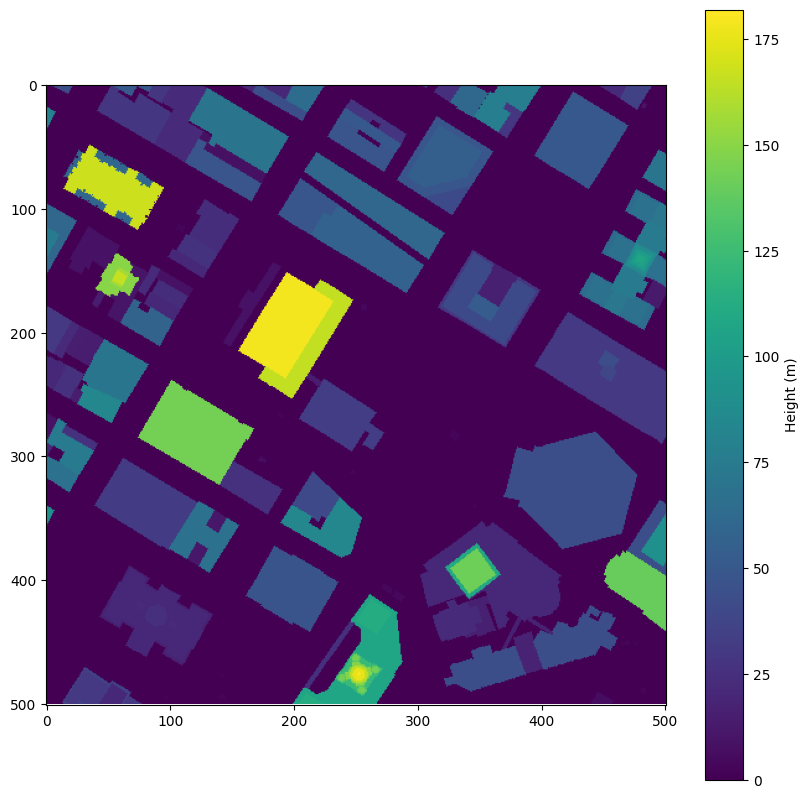

In [5]:
overture_map = np.load(Path(DATA_DIR) / "2D_Building_Height_Map.npy")

# show overture map with colormap
plt.figure(figsize=(10, 10))
plt.imshow(overture_map, cmap="viridis", origin="upper")
# show scale of colors
plt.colorbar(label="Height (m)")
plt.show()

In [6]:
overture_sionna_scene = scene.load_scene(DATA_DIR + "/scene.xml")
overture_sionna_scene.preview()

2026-06-29 17:28:13 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
